# Cervical Cancer Cell Classification - 10 Deep Learning Models

This notebook trains and benchmarks **10 deep-learning architectures** on SIPaKMeD:

| # | Model | Type | Pretrained |
|---|-------|------|------------|
| 1 | EfficientNet-B3 | CNN | ImageNet |
| 2 | MobileNetV3-Large | CNN | ImageNet |
| 3 | ViT-B/16 | Transformer | ImageNet |
| 4 | ResNet50 | CNN | ImageNet |
| 5 | DenseNet121 | CNN | ImageNet |
| 6 | VGG16 | CNN | ImageNet |
| 7 | Inception-V3 | CNN | ImageNet |
| 8 | ConvNeXt-Tiny | CNN | ImageNet |
| 9 | Swin-Tiny | Transformer | ImageNet |
| 10 | Custom CNN | CNN (from scratch) | None - baseline |

Uses the exact same data path, augmentation pipeline and dataset class as your reference notebook.


## STEP 1: Setup

In [26]:
!pip install -q timm albumentations --upgrade

In [28]:
!pip install -q timm==0.9.12

In [29]:
import os, random, json, copy, time, warnings
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter

import torchvision.models as tv_models
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, accuracy_score
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


In [30]:
# Reproducibility
SEED = 42
random.seed(SEED);  np.random.seed(SEED)
torch.manual_seed(SEED);  torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## STEP 2: Paths & Configuration

In [31]:
# Same path as your reference notebook
DATA_DIR   = '/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed'
SAVE_DIR   = '/kaggle/working/checkpoints'
RESULT_DIR = '/kaggle/working/results'

os.makedirs(SAVE_DIR,   exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("DATA_DIR  :", DATA_DIR)
print("SAVE_DIR  :", SAVE_DIR)
print("RESULT_DIR:", RESULT_DIR)

DATA_DIR  : /kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed
SAVE_DIR  : /kaggle/working/checkpoints
RESULT_DIR: /kaggle/working/results


In [33]:
# Classes (same as reference)
CLASS_NAMES = [
    'im_Dyskeratotic',
    'im_Koilocytotic',
    'im_Metaplastic',
    'im_Parabasal',
    'im_Superficial-Intermediate',
]
NUM_CLASSES  = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
SHORT_NAMES  = ['Dyskerat.', 'Koilocyt.', 'Metaplas.', 'Parabasal', 'Sup-Int.']

In [34]:
# Hyperparameters
IMG_SIZE     = 224       # default for 9 of 10 models
INCEPT_SIZE  = 299       # Inception-V3 only
BATCH_SIZE   = 16
LR           = 1e-4
EPOCHS       = 20        # reduced from 30 so all 10 models fit in one Kaggle session
NUM_WORKERS  = 2

TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15

print("Config ready")
print(f"Classes: {CLASS_NAMES}")

Config ready
Classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']


## STEP 3: Data Augmentation (same as reference: Albumentations + CLAHE)

In [35]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def get_transforms(phase: str, img_size: int = IMG_SIZE):
    if phase == 'train':
        return A.Compose([
            A.Resize(img_size + 32, img_size + 32),
            A.RandomCrop(img_size, img_size),

            A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),

            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),

            A.Affine(
                rotate=(-30, 30),
                scale=(0.85, 1.15),
                translate_percent=(-0.1, 0.1),
                shear=(-10, 10),
                p=0.7
            ),

            A.RandomBrightnessContrast(0.3, 0.3, p=0.6),
            A.HueSaturationValue(15, 25, 20, p=0.4),

            A.OneOf([
                A.GaussNoise(std_range=(0.02, 0.08)),
                A.ISONoise(color_shift=(0.01, 0.05)),
            ], p=0.4),

            A.OneOf([
                A.GaussianBlur(blur_limit=(3, 5)),
                A.MotionBlur(blur_limit=5),
            ], p=0.3),

            A.CoarseDropout(
                num_holes_range=(1, 6),
                hole_height_range=(8, 16),
                hole_width_range=(8, 16),
                p=0.3
            ),

            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])

print("Transforms defined")

Transforms defined


## STEP 4: Dataset & Loaders (uses os.walk - handles nested SIPaKMeD layout)

In [36]:
VALID_EXTS = {'.bmp', '.jpg', '.jpeg', '.png', '.tiff', '.tif'}

class SipakMedDataset(Dataset):
    def __init__(self, samples: list, transform: A.Compose):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label

In [37]:
def load_all_samples(root: str) -> list:
    """Walks recursively into each class folder - this handles the
    double-nested SIPaKMeD layout (im_X/im_X/*.bmp) used in this dataset."""
    samples = []
    for cls_name in CLASS_NAMES:
        cls_dir = os.path.join(root, cls_name)
        if not os.path.isdir(cls_dir):
            print(f"WARNING: missing class dir: {cls_dir}")
            continue
        label = CLASS_TO_IDX[cls_name]
        n_before = len(samples)
        for root_dir, _, files in os.walk(cls_dir):
            # Skip CROPPED subfolders (they are zoomed cell crops of the same images)
            if 'CROPPED' in root_dir.upper():
                continue
            for fname in files:
                if os.path.splitext(fname)[1].lower() in VALID_EXTS:
                    samples.append((os.path.join(root_dir, fname), label))
        print(f"  {cls_name:38s} {len(samples) - n_before} images")
    print(f"Total samples loaded: {len(samples)}")
    return samples

def make_splits(all_samples: list, seed: int = SEED):
    random.seed(seed)
    random.shuffle(all_samples)
    n       = len(all_samples)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    train_s = all_samples[:n_train]
    val_s   = all_samples[n_train:n_train + n_val]
    test_s  = all_samples[n_train + n_val:]
    print(f"Split -> Train: {len(train_s)} | Val: {len(val_s)} | Test: {len(test_s)}")
    return train_s, val_s, test_s

In [38]:
# Build splits ONCE - reused by all 10 models
all_samples            = load_all_samples(DATA_DIR)
train_s, val_s, test_s = make_splits(all_samples)

dist = Counter([s[1] for s in all_samples])
print("\nClass distribution:")
for idx, count in sorted(dist.items()):
    print(f"  {CLASS_NAMES[idx]:38s} {count}")

assert len(all_samples) > 0, "No samples loaded - check DATA_DIR path!" 

  im_Dyskeratotic                        223 images
  im_Koilocytotic                        238 images
  im_Metaplastic                         271 images
  im_Parabasal                           108 images
  im_Superficial-Intermediate            126 images
Total samples loaded: 966
Split -> Train: 676 | Val: 144 | Test: 146

Class distribution:
  im_Dyskeratotic                        223
  im_Koilocytotic                        238
  im_Metaplastic                         271
  im_Parabasal                           108
  im_Superficial-Intermediate            126


In [40]:
# Helper to build loaders for any image size
def make_loaders(img_size: int):
    tr_ds  = SipakMedDataset(train_s, get_transforms('train', img_size))
    val_ds = SipakMedDataset(val_s,   get_transforms('val',   img_size))
    te_ds  = SipakMedDataset(test_s,  get_transforms('test',  img_size))
    tr_ld  = DataLoader(tr_ds,  batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=NUM_WORKERS, pin_memory=True)
    val_ld = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
    te_ld  = DataLoader(te_ds,  batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
    return tr_ld, val_ld, te_ld

# Default loaders (224x224) - used by 9 of the 10 models
train_loader, val_loader, test_loader = make_loaders(IMG_SIZE)
print("Loaders ready")

Loaders ready


## STEP 5: Model Definitions (10 architectures)

In [42]:
# 5.1 EfficientNet-B3
def build_efficientnet(num_classes=NUM_CLASSES, pretrained=True):
    weights = tv_models.EfficientNet_B3_Weights.IMAGENET1K_V1 if pretrained else None
    model = tv_models.efficientnet_b3(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

In [44]:
# 5.2 MobileNetV3-Large
def build_mobilenet(num_classes=NUM_CLASSES, pretrained=True):
    weights = tv_models.MobileNet_V3_Large_Weights.IMAGENET1K_V2 if pretrained else None
    model = tv_models.mobilenet_v3_large(weights=weights)
    model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    return model

In [47]:
# 5.3 ViT-B/16
def build_vit(num_classes=NUM_CLASSES, pretrained=True):
    return timm.create_model('vit_base_patch16_224',
                             pretrained=pretrained,
                             num_classes=num_classes,
                             img_size=IMG_SIZE)

In [48]:
# 5.4 ResNet50
def build_resnet50(num_classes=NUM_CLASSES, pretrained=True):
    weights = tv_models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
    model = tv_models.resnet50(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [50]:
# 5.5 DenseNet121
def build_densenet121(num_classes=NUM_CLASSES, pretrained=True):
    weights = tv_models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
    model = tv_models.densenet121(weights=weights)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model

In [53]:
# 5.6 VGG16
def build_vgg16(num_classes=NUM_CLASSES, pretrained=True):
    weights = tv_models.VGG16_Weights.IMAGENET1K_V1 if pretrained else None
    model = tv_models.vgg16(weights=weights)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    return model

In [54]:
# 5.7 Inception-V3 (needs 299x299 input)
def build_inception_v3(num_classes=NUM_CLASSES, pretrained=True):
    weights = tv_models.Inception_V3_Weights.IMAGENET1K_V1 if pretrained else None
    model = tv_models.inception_v3(weights=weights, aux_logits=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
    return model

In [56]:
# 5.8 ConvNeXt-Tiny
def build_convnext_tiny(num_classes=NUM_CLASSES, pretrained=True):
    weights = tv_models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None
    model = tv_models.convnext_tiny(weights=weights)
    model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
    return model

In [57]:
# 5.9 Swin-Tiny
def build_swin_tiny(num_classes=NUM_CLASSES, pretrained=True):
    return timm.create_model('swin_tiny_patch4_window7_224',
                             pretrained=pretrained,
                             num_classes=num_classes)

In [58]:
# 5.10 Custom CNN (from scratch - baseline)
class CustomCNN(nn.Module):
    """Simple from-scratch CNN. Shows how much pretraining matters."""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            block(3, 32), block(32, 64), block(64, 128), block(128, 256), block(256, 512),
        )
        self.gap        = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.5), nn.Linear(512, num_classes))

    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))

def build_custom_cnn(num_classes=NUM_CLASSES, pretrained=False):
    return CustomCNN(num_classes)

In [59]:
# Master registry: name -> (builder, input_size, uses_pretrained)
MODEL_REGISTRY = {
    'efficientnet_b3': (build_efficientnet,  IMG_SIZE,    True),
    'mobilenet_v3':    (build_mobilenet,     IMG_SIZE,    True),
    'vit_b16':         (build_vit,           IMG_SIZE,    True),
    'resnet50':        (build_resnet50,      IMG_SIZE,    True),
    'densenet121':     (build_densenet121,   IMG_SIZE,    True),
    'vgg16':           (build_vgg16,         IMG_SIZE,    True),
    'inception_v3':    (build_inception_v3,  INCEPT_SIZE, True),
    'convnext_tiny':   (build_convnext_tiny, IMG_SIZE,    True),
    'swin_tiny':       (build_swin_tiny,     IMG_SIZE,    True),
    'custom_cnn':      (build_custom_cnn,    IMG_SIZE,    False),
}
MODEL_NAMES = list(MODEL_REGISTRY.keys())
print(f"Registered {len(MODEL_NAMES)} models:")
for n in MODEL_NAMES:
    print(f"  - {n}")

Registered 10 models:
  - efficientnet_b3
  - mobilenet_v3
  - vit_b16
  - resnet50
  - densenet121
  - vgg16
  - inception_v3
  - convnext_tiny
  - swin_tiny
  - custom_cnn


## STEP 6: Training Utilities

In [60]:
def train_one_epoch(model, loader, criterion, optimizer, is_inception=False):
    model.train()
    running_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        if is_inception:
            outs, aux = model(imgs)
            loss = criterion(outs, labels) + 0.4 * criterion(aux, labels)
        else:
            outs = model(imgs)
            loss = criterion(outs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
    return running_loss / total, correct / total

In [61]:
@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    running_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outs = model(imgs)
        if isinstance(outs, tuple): outs = outs[0]
        loss = criterion(outs, labels)
        running_loss += loss.item() * imgs.size(0)
        preds = outs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
    return running_loss / total, correct / total

In [62]:
@torch.no_grad()
def get_probs_and_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        outs = model(imgs)
        if isinstance(outs, tuple): outs = outs[0]
        probs = torch.softmax(outs, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

In [63]:
def measure_inference_time(model, loader, n_batches=10):
    model.eval()
    times = []
    with torch.no_grad():
        for i, (imgs, _) in enumerate(loader):
            if i >= n_batches: break
            imgs = imgs.to(DEVICE)
            if torch.cuda.is_available(): torch.cuda.synchronize()
            t0 = time.time()
            out = model(imgs)
            if isinstance(out, tuple): out = out[0]
            if torch.cuda.is_available(): torch.cuda.synchronize()
            elapsed = (time.time() - t0) * 1000
            times.append(elapsed / imgs.size(0))
    return float(np.mean(times))

In [64]:
def train_model(name, model, train_ld, val_ld, epochs=EPOCHS):
    print(f"\n{'='*60}\n  Training: {name}\n{'='*60}")
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    is_inception = (name == 'inception_v3')

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state   = None

    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_ld, criterion, optimizer, is_inception)
        vl_loss, vl_acc = validate(model, val_ld, criterion)
        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)

        marker = ""
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = copy.deepcopy(model.state_dict())
            marker = " *"
        print(f"  Ep {ep:02d}/{epochs} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"val loss {vl_loss:.4f} acc {vl_acc:.4f} | "
              f"{time.time()-t0:5.1f}s{marker}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_val_acc

## STEP 7: Train All 10 Models

Each model trained independently. If any model fails (OOM etc.) the loop continues
with the next. Weights saved to disk after each model finishes.

In [65]:
# Storage for everything
trained_models = {}      # name -> trained model
all_histories  = {}      # name -> training history
all_val_accs   = {}      # name -> best val accuracy
all_probs      = {}      # name -> test set probabilities (N, C)
all_inf_times  = {}      # name -> inference ms/img
all_param_cnts = {}      # name -> parameter count (millions)
labels_test    = None    # true labels (set on first model)

print(f"Training {len(MODEL_NAMES)} models for {EPOCHS} epochs each.")
print(f"Estimated time on T4: ~6-10 hours.")

Training 10 models for 20 epochs each.
Estimated time on T4: ~6-10 hours.


In [66]:
# === MAIN TRAINING LOOP ===
for name in MODEL_NAMES:
    builder, img_size, pretr = MODEL_REGISTRY[name]

    # Inception needs 299x299 loaders, others reuse the default 224x224 ones
    if img_size != IMG_SIZE:
        tr_ld, val_ld, te_ld = make_loaders(img_size)
    else:
        tr_ld, val_ld, te_ld = train_loader, val_loader, test_loader

    try:
        model = builder(pretrained=pretr)
        model, hist, best_val = train_model(name, model, tr_ld, val_ld, EPOCHS)

        # Save weights immediately so a crash later doesn't lose progress
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, f'{name}.pth'))

        probs, labels = get_probs_and_labels(model, te_ld)
        if labels_test is None:
            labels_test = labels

        inf_ms   = measure_inference_time(model, te_ld, n_batches=10)
        n_params = sum(p.numel() for p in model.parameters()) / 1e6

        trained_models[name] = model
        all_histories[name]  = hist
        all_val_accs[name]   = best_val
        all_probs[name]      = probs
        all_inf_times[name]  = inf_ms
        all_param_cnts[name] = n_params

        test_acc = (probs.argmax(1) == labels).mean()
        print(f"\n  DONE {name}. Test acc: {test_acc:.4f} | Params: {n_params:.2f}M | Inf: {inf_ms:.2f} ms/img")

        del model
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"\n  FAIL {name}: {type(e).__name__}: {e}")
        torch.cuda.empty_cache()
        continue

print(f"\n{'='*60}\n  Training complete: {len(trained_models)}/{len(MODEL_NAMES)} models succeeded\n{'='*60}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 166MB/s] 



  Training: efficientnet_b3
  Ep 01/20 | train loss 1.5291 acc 0.3521 | val loss 1.3826 acc 0.5833 |  95.4s *
  Ep 02/20 | train loss 1.2496 acc 0.5799 | val loss 0.9753 acc 0.7569 |   8.8s *
  Ep 03/20 | train loss 0.9153 acc 0.7101 | val loss 0.5990 acc 0.8194 |   8.8s *
  Ep 04/20 | train loss 0.6946 acc 0.7559 | val loss 0.4955 acc 0.8194 |   8.8s
  Ep 05/20 | train loss 0.5592 acc 0.8062 | val loss 0.3728 acc 0.8750 |   8.9s *
  Ep 06/20 | train loss 0.5081 acc 0.8254 | val loss 0.3267 acc 0.8889 |   9.0s *
  Ep 07/20 | train loss 0.4800 acc 0.8254 | val loss 0.2974 acc 0.9028 |   9.0s *
  Ep 08/20 | train loss 0.3856 acc 0.8654 | val loss 0.2596 acc 0.9236 |   9.1s *
  Ep 09/20 | train loss 0.3816 acc 0.8743 | val loss 0.2363 acc 0.9236 |   9.1s
  Ep 10/20 | train loss 0.2882 acc 0.9024 | val loss 0.2289 acc 0.9444 |   9.2s *
  Ep 11/20 | train loss 0.3027 acc 0.9053 | val loss 0.2092 acc 0.9306 |   9.2s
  Ep 12/20 | train loss 0.3123 acc 0.8787 | val loss 0.2415 acc 0.9097 |   

100%|██████████| 21.1M/21.1M [00:00<00:00, 116MB/s] 



  Training: mobilenet_v3
  Ep 01/20 | train loss 1.3510 acc 0.4275 | val loss 1.0990 acc 0.6250 |  10.3s *
  Ep 02/20 | train loss 0.8588 acc 0.7263 | val loss 0.5830 acc 0.7778 |   7.8s *
  Ep 03/20 | train loss 0.5716 acc 0.8107 | val loss 0.3298 acc 0.8681 |   7.9s *
  Ep 04/20 | train loss 0.4371 acc 0.8536 | val loss 0.2864 acc 0.8958 |   7.9s *
  Ep 05/20 | train loss 0.4232 acc 0.8624 | val loss 0.2985 acc 0.8889 |   8.0s
  Ep 06/20 | train loss 0.3958 acc 0.8491 | val loss 0.2401 acc 0.8958 |   7.9s
  Ep 07/20 | train loss 0.3322 acc 0.8743 | val loss 0.2170 acc 0.9167 |   7.9s *
  Ep 08/20 | train loss 0.2886 acc 0.8920 | val loss 0.1850 acc 0.9167 |   8.0s
  Ep 09/20 | train loss 0.2557 acc 0.9172 | val loss 0.2338 acc 0.9097 |   8.0s
  Ep 10/20 | train loss 0.2641 acc 0.8979 | val loss 0.1912 acc 0.9306 |   8.0s *
  Ep 11/20 | train loss 0.2743 acc 0.9068 | val loss 0.2458 acc 0.9028 |   7.8s
  Ep 12/20 | train loss 0.1943 acc 0.9320 | val loss 0.1928 acc 0.9306 |   7.9s
  

...


  Training: inception_v3
  Ep 01/20 | train loss 1.6530 acc 0.5118 | val loss 0.6000 acc 0.8264 |  14.1s *
  Ep 02/20 | train loss 0.8712 acc 0.7648 | val loss 0.3446 acc 0.8819 |  13.7s *
  Ep 03/20 | train loss 0.6619 acc 0.8284 | val loss 0.2853 acc 0.9028 |  13.8s *
  Ep 04/20 | train loss 0.5147 acc 0.8802 | val loss 0.2240 acc 0.9236 |  13.7s *
  Ep 05/20 | train loss 0.5114 acc 0.8713 | val loss 0.2721 acc 0.9167 |  13.7s
  Ep 06/20 | train loss 0.4653 acc 0.8964 | val loss 0.3058 acc 0.8750 |  13.6s
  Ep 07/20 | train loss 0.3999 acc 0.9038 | val loss 0.1898 acc 0.9444 |  13.7s *
  Ep 08/20 | train loss 0.3419 acc 0.9127 | val loss 0.2521 acc 0.9236 |  13.7s
  Ep 09/20 | train loss 0.2506 acc 0.9408 | val loss 0.1989 acc 0.9167 |  13.8s
  Ep 10/20 | train loss 0.2792 acc 0.9246 | val loss 0.2461 acc 0.9167 |  13.7s
  Ep 11/20 | train loss 0.3559 acc 0.9216 | val loss 0.2121 acc 0.8958 |  13.6s
  Ep 12/20 | train loss 0.2555 acc 0.9290 | val loss 0.2239 acc 0.9097 |  13.6s
  Ep

100%|██████████| 109M/109M [00:00<00:00, 169MB/s] 



  Training: convnext_tiny
  Ep 01/20 | train loss 1.0328 acc 0.5888 | val loss 0.4601 acc 0.8542 |  23.2s *
  Ep 02/20 | train loss 0.4971 acc 0.8166 | val loss 0.2979 acc 0.8819 |  15.6s *
  Ep 03/20 | train loss 0.3379 acc 0.8802 | val loss 0.2027 acc 0.9236 |  15.7s *
  Ep 04/20 | train loss 0.2949 acc 0.8994 | val loss 0.2110 acc 0.9167 |  15.5s
  Ep 05/20 | train loss 0.2640 acc 0.9024 | val loss 0.1474 acc 0.9375 |  15.4s *
  Ep 06/20 | train loss 0.2332 acc 0.9142 | val loss 0.1709 acc 0.9444 |  15.4s *
  Ep 07/20 | train loss 0.2047 acc 0.9275 | val loss 0.2017 acc 0.9306 |  15.4s
  Ep 08/20 | train loss 0.1388 acc 0.9541 | val loss 0.1758 acc 0.9444 |  15.5s
  Ep 09/20 | train loss 0.1830 acc 0.9482 | val loss 0.2020 acc 0.9375 |  15.5s
  Ep 10/20 | train loss 0.1312 acc 0.9556 | val loss 0.2255 acc 0.9167 |  15.4s
  Ep 11/20 | train loss 0.0905 acc 0.9719 | val loss 0.1976 acc 0.9375 |  15.4s
  Ep 12/20 | train loss 0.0978 acc 0.9630 | val loss 0.2618 acc 0.9097 |  15.4s
  E

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


  Training: swin_tiny
  Ep 01/20 | train loss 1.0401 acc 0.5888 | val loss 0.6663 acc 0.7292 |  11.4s *
  Ep 02/20 | train loss 0.5764 acc 0.7899 | val loss 0.3906 acc 0.8472 |  11.0s *
  Ep 03/20 | train loss 0.4938 acc 0.8254 | val loss 0.2744 acc 0.9097 |  11.0s *
  Ep 04/20 | train loss 0.4167 acc 0.8536 | val loss 0.1889 acc 0.9514 |  11.0s *
  Ep 05/20 | train loss 0.3222 acc 0.8994 | val loss 0.2369 acc 0.8958 |  10.9s
  Ep 06/20 | train loss 0.3160 acc 0.8802 | val loss 0.3427 acc 0.8889 |  10.9s
  Ep 07/20 | train loss 0.2438 acc 0.9038 | val loss 0.1875 acc 0.9375 |  10.9s
  Ep 08/20 | train loss 0.2375 acc 0.9157 | val loss 0.2513 acc 0.9097 |  10.9s
  Ep 09/20 | train loss 0.2157 acc 0.9349 | val loss 0.2633 acc 0.9028 |  10.9s
  Ep 10/20 | train loss 0.1894 acc 0.9393 | val loss 0.1626 acc 0.9514 |  10.9s
  Ep 11/20 | train loss 0.2010 acc 0.9379 | val loss 0.1583 acc 0.9444 |  10.9s
  Ep 12/20 | train loss 0.1957 acc 0.9275 | val loss 0.2350 acc 0.9167 |  10.9s
  Ep 13/2

In [67]:
# Persist artifacts in case the kernel restarts later
np.savez(os.path.join(RESULT_DIR, 'all_probs.npz'), **all_probs, labels=labels_test)
with open(os.path.join(RESULT_DIR, 'all_histories.json'), 'w') as f:
    json.dump(all_histories, f, indent=2)
with open(os.path.join(RESULT_DIR, 'val_accs.json'), 'w') as f:
    json.dump({k: float(v) for k, v in all_val_accs.items()}, f, indent=2)
with open(os.path.join(RESULT_DIR, 'inference_times.json'), 'w') as f:
    json.dump({k: float(v) for k, v in all_inf_times.items()}, f, indent=2)
with open(os.path.join(RESULT_DIR, 'param_counts.json'), 'w') as f:
    json.dump({k: float(v) for k, v in all_param_cnts.items()}, f, indent=2)
print(f"All artifacts saved to: {RESULT_DIR}")

All artifacts saved to: /kaggle/working/results


## STEP 8: Per-Model Performance Metrics

In [68]:
results = {}
y_bin = label_binarize(labels_test, classes=list(range(NUM_CLASSES)))

for name in trained_models:
    probs = all_probs[name]
    preds = probs.argmax(1)
    results[name] = {
        'accuracy':     accuracy_score(labels_test, preds),
        'f1_macro':     f1_score(labels_test, preds, average='macro'),
        'f1_weighted':  f1_score(labels_test, preds, average='weighted'),
        'auc_macro':    roc_auc_score(y_bin, probs, average='macro', multi_class='ovr'),
        'per_class_f1': f1_score(labels_test, preds, average=None).tolist(),
        'params_M':     all_param_cnts[name],
        'inference_ms': all_inf_times[name],
        'val_acc':      all_val_accs[name],
    }

df = pd.DataFrame([{
    'Model':       name,
    'Params (M)':  f"{r['params_M']:.2f}",
    'Inf (ms)':    f"{r['inference_ms']:.2f}",
    'Val Acc':     f"{r['val_acc']:.4f}",
    'Test Acc':    f"{r['accuracy']:.4f}",
    'F1 Macro':    f"{r['f1_macro']:.4f}",
    'F1 Weighted': f"{r['f1_weighted']:.4f}",
    'AUC Macro':   f"{r['auc_macro']:.4f}",
} for name, r in results.items()])
df = df.sort_values('Test Acc', ascending=False).reset_index(drop=True)
df.to_csv(os.path.join(RESULT_DIR, 'model_comparison.csv'), index=False)
print(df.to_string(index=False))

          Model Params (M) Inf (ms) Val Acc Test Acc F1 Macro F1 Weighted AUC Macro
       resnet50      23.52     2.99  0.9444   0.9589   0.9647      0.9592    0.9958
    densenet121       6.96     3.74  0.9444   0.9521   0.9589      0.9517    0.9982
          vgg16     134.28     5.36  0.9375   0.9384   0.9496      0.9376    0.9953
  convnext_tiny      27.82     4.26  0.9653   0.9384   0.9480      0.9378    0.9942
efficientnet_b3      10.70     3.46  0.9444   0.9247   0.9317      0.9242    0.9951
   mobilenet_v3       4.21     1.42  0.9375   0.9178   0.9315      0.9180    0.9962
   inception_v3      24.36     4.18  0.9444   0.9178   0.9303      0.9182    0.9963
      swin_tiny      27.52     4.51  0.9514   0.9110   0.9209      0.9088    0.9929
        vit_b16      85.80    12.76  0.9444   0.9041   0.9163      0.9026    0.9923
     custom_cnn       4.72     1.94  0.7708   0.7671   0.7628      0.7674    0.9523


In [69]:
# Per-class F1 table (rows = models, cols = classes)
per_class_df = pd.DataFrame(
    {name: r['per_class_f1'] for name, r in results.items()},
    index=SHORT_NAMES,
).T
per_class_df.to_csv(os.path.join(RESULT_DIR, 'per_class_f1.csv'))
print("Per-class F1:")
print(per_class_df.round(4))

Per-class F1:
                 Dyskerat.  Koilocyt.  Metaplas.  Parabasal  Sup-Int.
efficientnet_b3     0.9143     0.9143     0.9041     0.9714    0.9545
mobilenet_v3        0.8889     0.9118     0.8800     1.0000    0.9767
vit_b16             0.8333     0.9041     0.8916     1.0000    0.9524
resnet50            0.9315     0.9429     0.9722     1.0000    0.9767
densenet121         0.9444     0.9459     0.9275     1.0000    0.9767
vgg16               0.9296     0.8955     0.9231     1.0000    1.0000
inception_v3        0.8857     0.8986     0.8974     0.9697    1.0000
convnext_tiny       0.9429     0.8889     0.9315     1.0000    0.9767
swin_tiny           0.9167     0.8358     0.9189     1.0000    0.9333
custom_cnn          0.7619     0.7273     0.8333     0.7317    0.7600


In [70]:
# Detailed classification report per model
for name in trained_models:
    print(f"\n{'='*60}\n  Classification Report: {name}\n{'='*60}")
    preds = all_probs[name].argmax(1)
    print(classification_report(labels_test, preds, target_names=SHORT_NAMES, digits=4))


  Classification Report: efficientnet_b3
              precision    recall  f1-score   support

   Dyskerat.     0.8889    0.9412    0.9143        34
   Koilocyt.     0.9697    0.8649    0.9143        37
   Metaplas.     0.9167    0.8919    0.9041        37
   Parabasal     0.9444    1.0000    0.9714        17
    Sup-Int.     0.9130    1.0000    0.9545        21

    accuracy                         0.9247       146
   macro avg     0.9265    0.9396    0.9317       146
weighted avg     0.9264    0.9247    0.9242       146


  Classification Report: mobilenet_v3
              precision    recall  f1-score   support

   Dyskerat.     0.8421    0.9412    0.8889        34
   Koilocyt.     1.0000    0.8378    0.9118        37
   Metaplas.     0.8684    0.8919    0.8800        37
   Parabasal     1.0000    1.0000    1.0000        17
    Sup-Int.     0.9545    1.0000    0.9767        21

    accuracy                         0.9178       146
   macro avg     0.9330    0.9342    0.9315       

## STEP 9: Comparison Plots

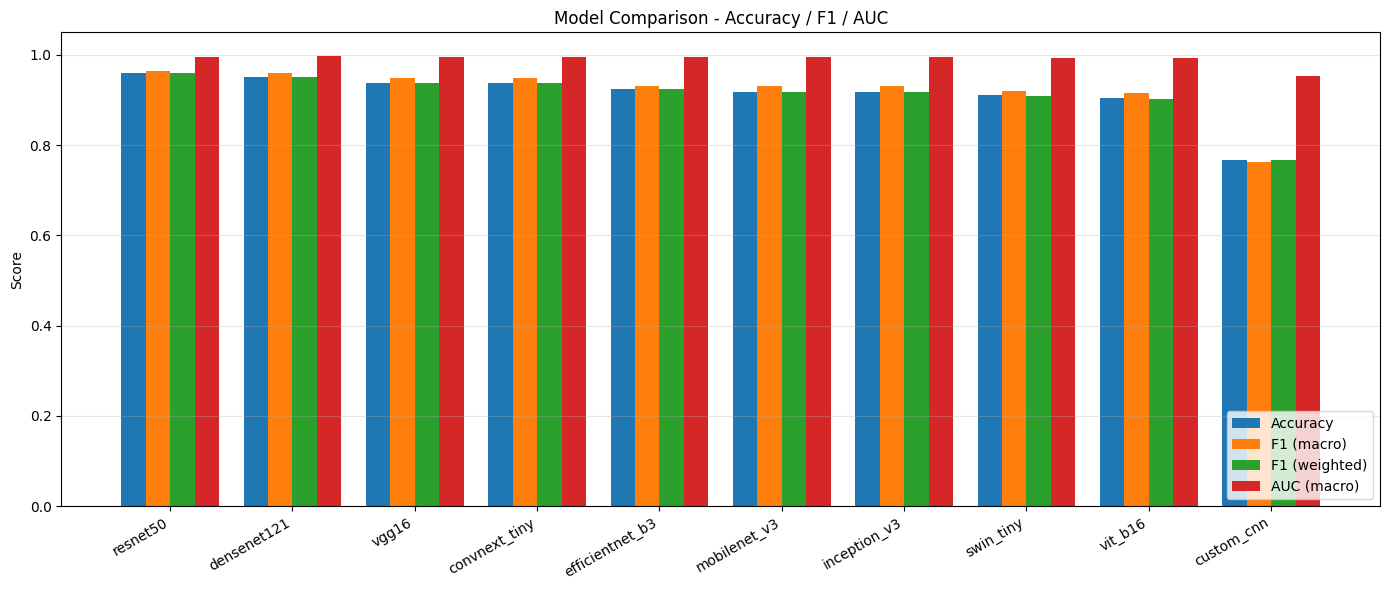

In [71]:
# 9.1 Grouped bar chart - Accuracy / F1 / AUC across all models
metrics_to_plot = ['accuracy', 'f1_macro', 'f1_weighted', 'auc_macro']
labels_to_plot  = ['Accuracy', 'F1 (macro)', 'F1 (weighted)', 'AUC (macro)']
names_sorted = sorted(results.keys(), key=lambda n: -results[n]['accuracy'])

x = np.arange(len(names_sorted))
width = 0.2
fig, ax = plt.subplots(figsize=(14, 6))
for i, (m, lab) in enumerate(zip(metrics_to_plot, labels_to_plot)):
    vals = [results[n][m] for n in names_sorted]
    ax.bar(x + (i - 1.5) * width, vals, width, label=lab)
ax.set_xticks(x); ax.set_xticklabels(names_sorted, rotation=30, ha='right')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison - Accuracy / F1 / AUC')
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'comparison_bars.png'), dpi=150, bbox_inches='tight')
plt.show()

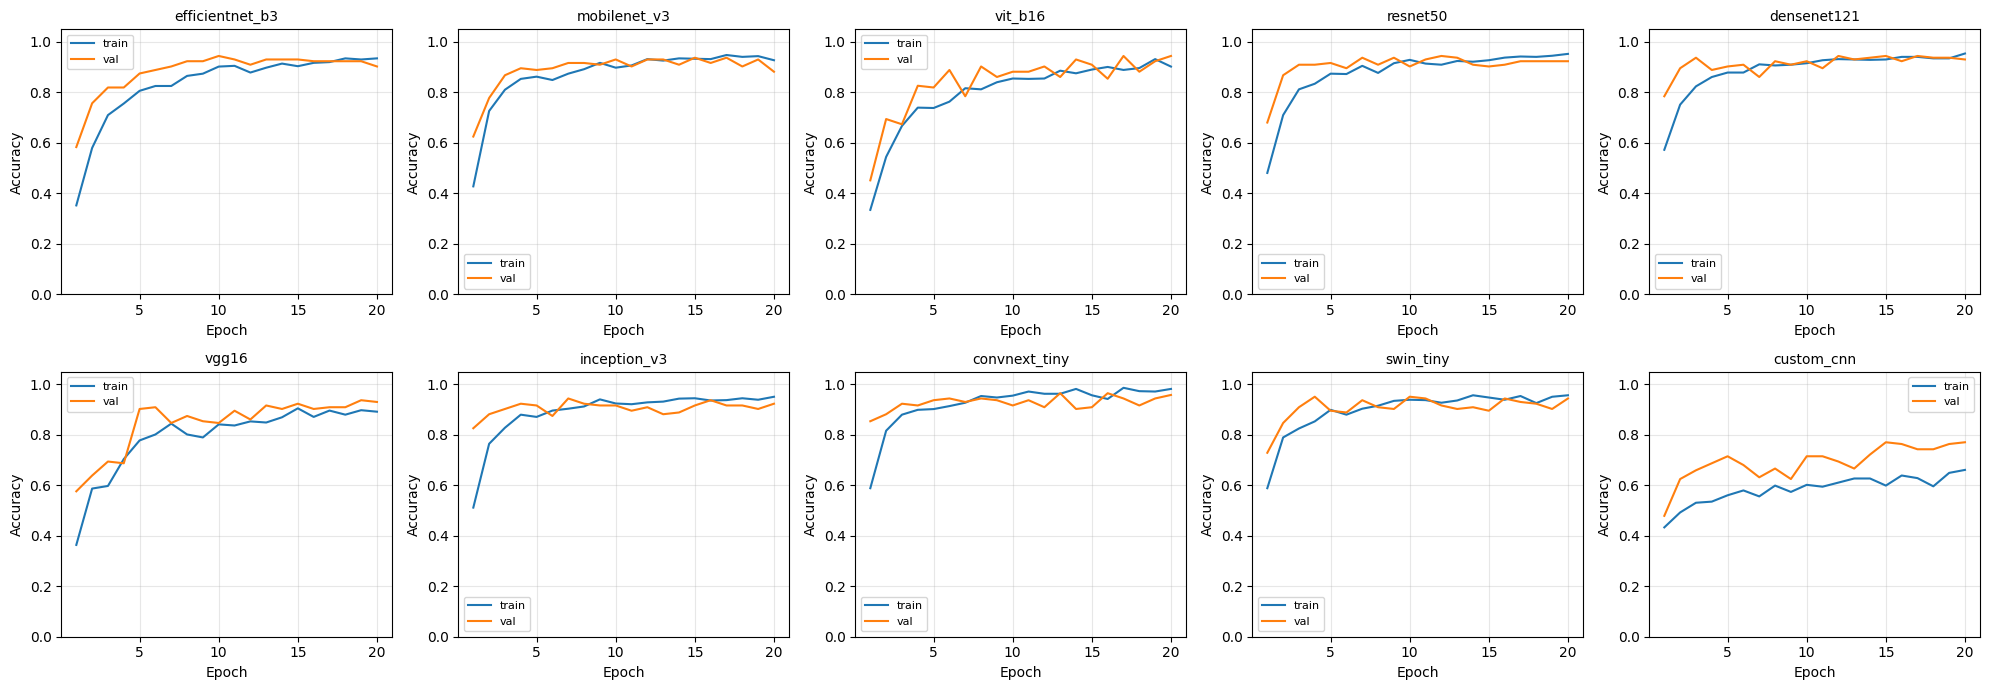

In [72]:
# 9.2 Training curves (accuracy) - 2x5 grid
n = len(all_histories)
ncols = 5; nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = axes.flatten() if n > 1 else [axes]
last_i = -1
for i, (name, h) in enumerate(all_histories.items()):
    ax = axes[i]
    ep = range(1, len(h['train_acc']) + 1)
    ax.plot(ep, h['train_acc'], label='train', linewidth=1.5)
    ax.plot(ep, h['val_acc'],   label='val',   linewidth=1.5)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    last_i = i
for j in range(last_i + 1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'training_curves_acc.png'), dpi=150, bbox_inches='tight')
plt.show()

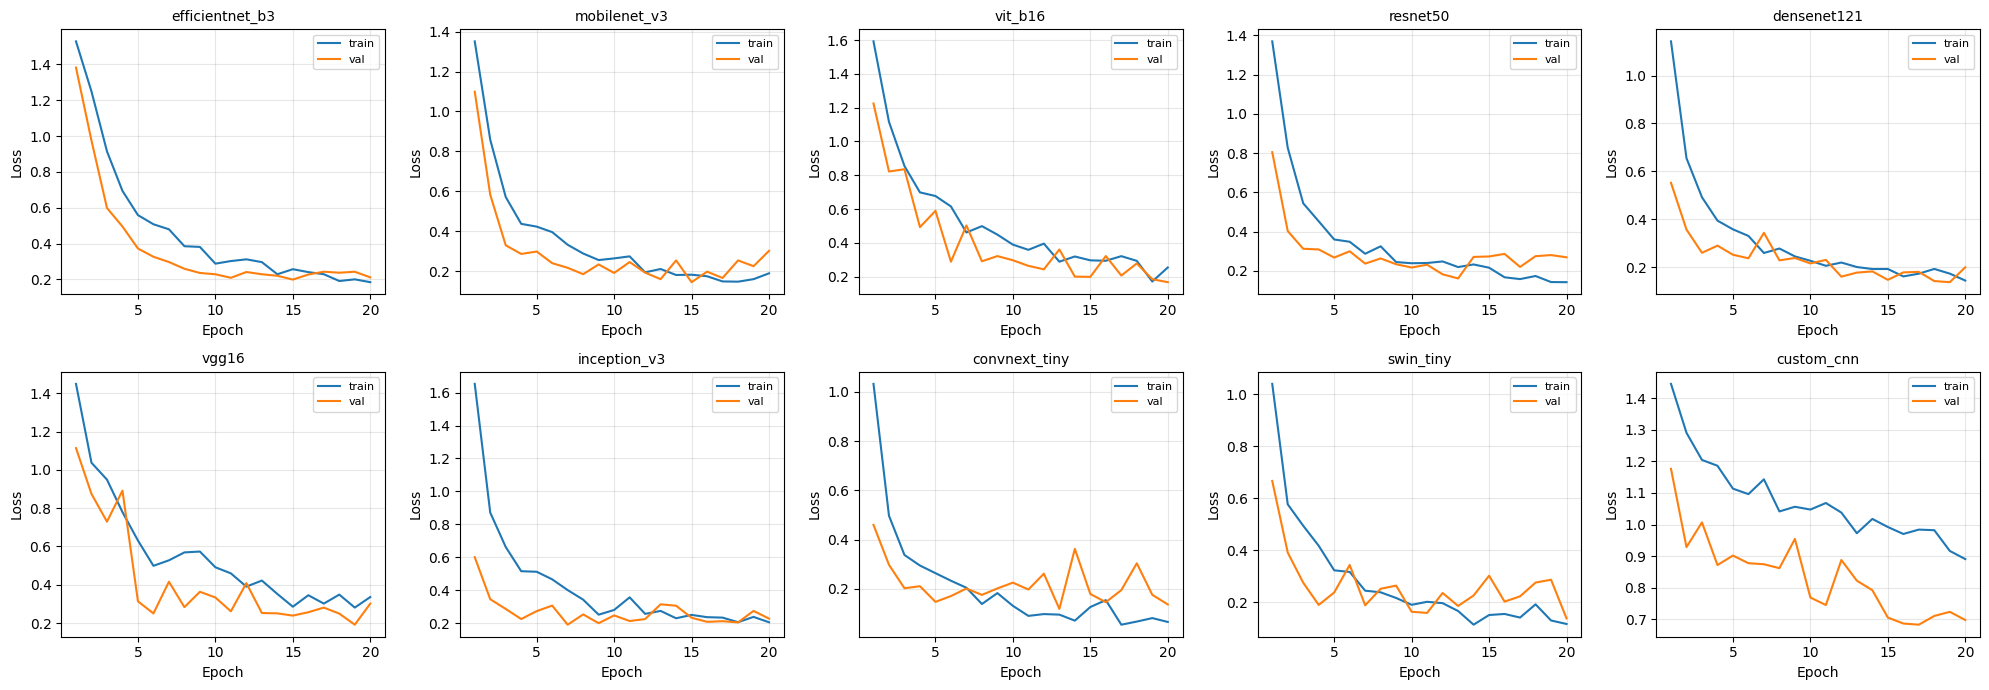

In [73]:
# 9.3 Training curves (loss)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = axes.flatten() if n > 1 else [axes]
last_i = -1
for i, (name, h) in enumerate(all_histories.items()):
    ax = axes[i]
    ep = range(1, len(h['train_loss']) + 1)
    ax.plot(ep, h['train_loss'], label='train', linewidth=1.5)
    ax.plot(ep, h['val_loss'],   label='val',   linewidth=1.5)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    last_i = i
for j in range(last_i + 1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'training_curves_loss.png'), dpi=150, bbox_inches='tight')
plt.show()

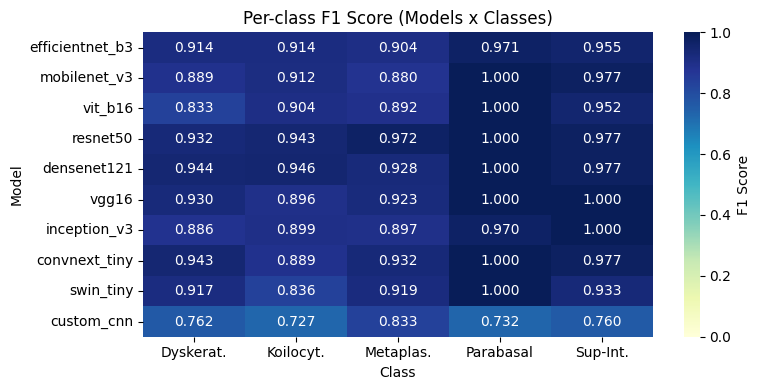

In [74]:
# 9.4 Per-class F1 heatmap
plt.figure(figsize=(8, max(4, 0.4 * len(per_class_df))))
sns.heatmap(per_class_df, annot=True, fmt='.3f', cmap='YlGnBu',
            cbar_kws={'label': 'F1 Score'}, vmin=0, vmax=1)
plt.title('Per-class F1 Score (Models x Classes)')
plt.xlabel('Class'); plt.ylabel('Model')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'per_class_f1_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

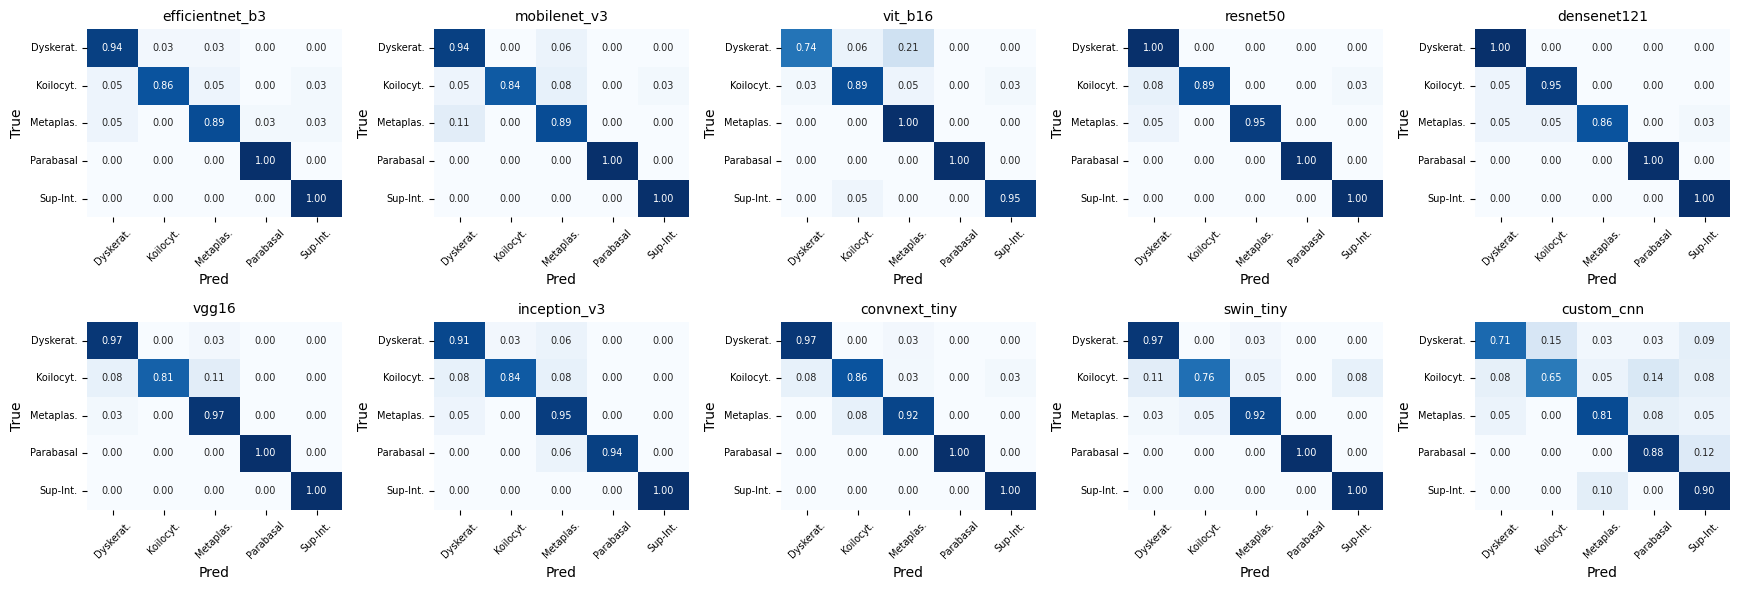

In [75]:
# 9.5 Confusion matrix grid (one per model)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3 * nrows))
axes = axes.flatten() if n > 1 else [axes]
last_i = -1
for i, name in enumerate(trained_models):
    cm = confusion_matrix(labels_test, all_probs[name].argmax(1))
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues', cbar=False,
                xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES, ax=axes[i],
                annot_kws={'size': 7})
    axes[i].set_title(name, fontsize=10)
    axes[i].set_xlabel('Pred'); axes[i].set_ylabel('True')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].tick_params(axis='y', rotation=0,  labelsize=7)
    last_i = i
for j in range(last_i + 1, len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

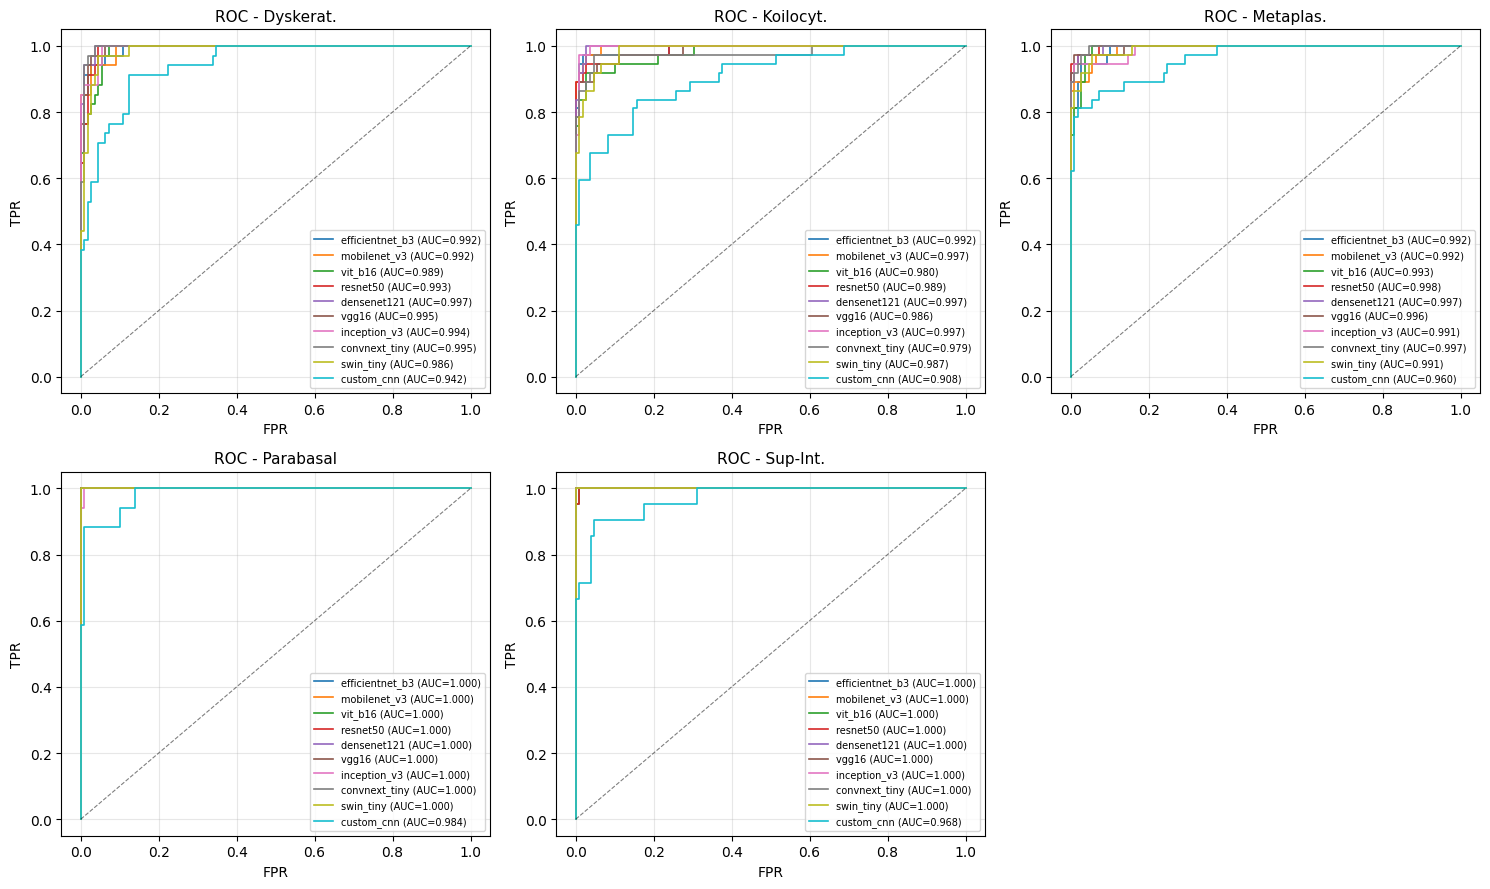

In [76]:
# 9.6 ROC curves overlay - one panel per class, all models on same panel
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, len(trained_models)))

for c, class_name in enumerate(SHORT_NAMES):
    ax = axes[c]
    for (name, probs), col in zip(all_probs.items(), colors):
        if name not in trained_models: continue
        fpr, tpr, _ = roc_curve(y_bin[:, c], probs[:, c])
        auc = roc_auc_score(y_bin[:, c], probs[:, c])
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=col, linewidth=1.2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'ROC - {class_name}', fontsize=11)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=7, loc='lower right'); ax.grid(alpha=0.3)
axes[5].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'roc_curves_per_class.png'), dpi=150, bbox_inches='tight')
plt.show()

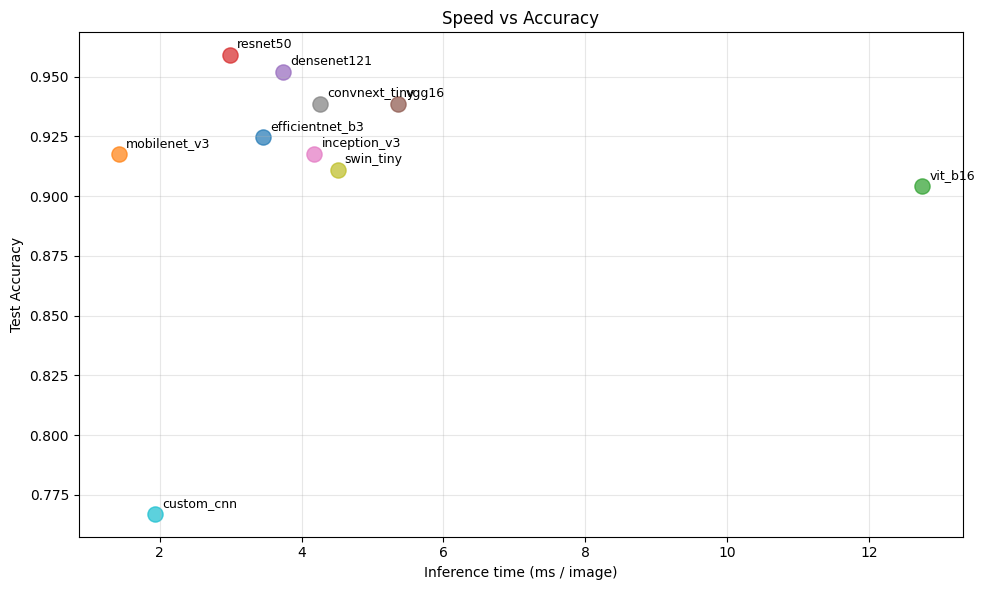

In [77]:
# 9.7 Speed vs Accuracy scatter
fig, ax = plt.subplots(figsize=(10, 6))
for name in trained_models:
    r = results[name]
    ax.scatter(r['inference_ms'], r['accuracy'], s=120, alpha=0.7)
    ax.annotate(name, (r['inference_ms'], r['accuracy']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('Inference time (ms / image)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Speed vs Accuracy')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'speed_vs_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

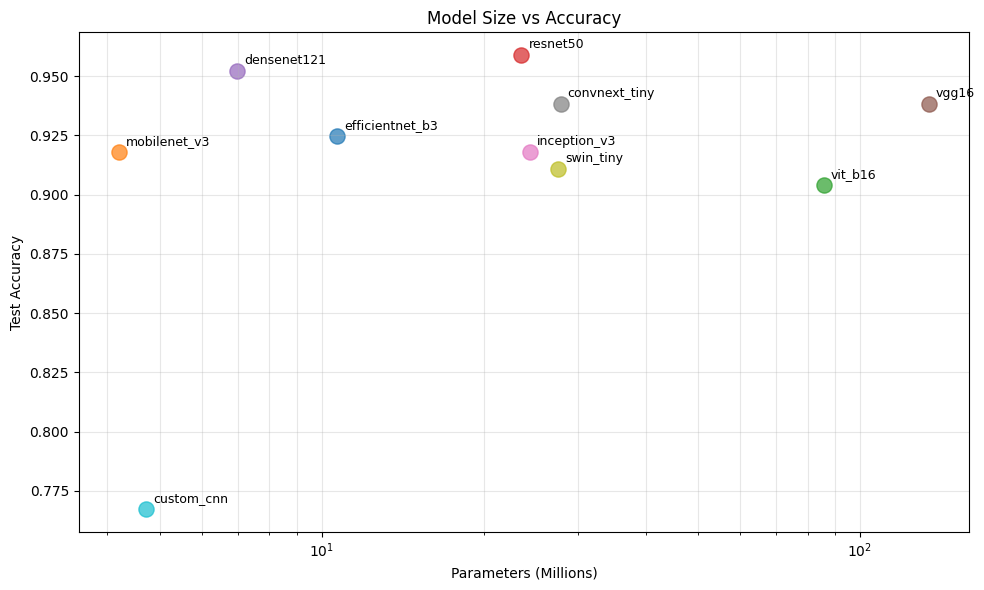

In [78]:
# 9.8 Model size vs Accuracy scatter (log-x)
fig, ax = plt.subplots(figsize=(10, 6))
for name in trained_models:
    r = results[name]
    ax.scatter(r['params_M'], r['accuracy'], s=120, alpha=0.7)
    ax.annotate(name, (r['params_M'], r['accuracy']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('Parameters (Millions)')
ax.set_ylabel('Test Accuracy')
ax.set_xscale('log')
ax.set_title('Model Size vs Accuracy')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'size_vs_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

## STEP 10: Final Report

In [79]:
print("\n" + "=" * 90)
print("  FINAL MODEL COMPARISON REPORT - 10 DEEP LEARNING ARCHITECTURES")
print("=" * 90)
print(f"\nDataset: SIPaKMeD ({len(all_samples)} images, {NUM_CLASSES} classes)")
print(f"Split:   {len(train_s)} train / {len(val_s)} val / {len(test_s)} test")
print(f"Epochs:  {EPOCHS}   |   Batch: {BATCH_SIZE}   |   LR: {LR}")
print(f"\n{'Model':<20} {'Params':>10} {'Inf(ms)':>10} {'Val Acc':>10} {'Test Acc':>10} {'F1 Mac':>10} {'AUC':>10}")
print("-" * 90)
for n in names_sorted:
    r = results[n]
    print(f"{n:<20} {r['params_M']:>9.2f}M {r['inference_ms']:>10.2f} "
          f"{r['val_acc']:>10.4f} {r['accuracy']:>10.4f} "
          f"{r['f1_macro']:>10.4f} {r['auc_macro']:>10.4f}")
print("=" * 90)

best_acc = max(results, key=lambda n: results[n]['accuracy'])
best_eff = max(results, key=lambda n: results[n]['accuracy'] / max(results[n]['params_M'], 0.1))
fastest  = min(results, key=lambda n: results[n]['inference_ms'])

print(f"\nBest accuracy        : {best_acc} ({results[best_acc]['accuracy']:.4f})")
print(f"Fastest inference    : {fastest} ({results[fastest]['inference_ms']:.2f} ms/img)")
print(f"Best efficiency      : {best_eff} (acc/params ratio)")


  FINAL MODEL COMPARISON REPORT - 10 DEEP LEARNING ARCHITECTURES

Dataset: SIPaKMeD (966 images, 5 classes)
Split:   676 train / 144 val / 146 test
Epochs:  20   |   Batch: 16   |   LR: 0.0001

Model                    Params    Inf(ms)    Val Acc   Test Acc     F1 Mac        AUC
------------------------------------------------------------------------------------------
resnet50                 23.52M       2.99     0.9444     0.9589     0.9647     0.9958
densenet121               6.96M       3.74     0.9444     0.9521     0.9589     0.9982
vgg16                   134.28M       5.36     0.9375     0.9384     0.9496     0.9953
convnext_tiny            27.82M       4.26     0.9653     0.9384     0.9480     0.9942
efficientnet_b3          10.70M       3.46     0.9444     0.9247     0.9317     0.9951
mobilenet_v3              4.21M       1.42     0.9375     0.9178     0.9315     0.9962
inception_v3             24.36M       4.18     0.9444     0.9178     0.9303     0.9963
swin_tiny         

In [81]:
final_report = {
    'dataset':       'SIPaKMeD',
    'data_dir':      DATA_DIR,
    'num_classes':   NUM_CLASSES,
    'class_names':   CLASS_NAMES,
    'splits':        {'train': len(train_s), 'val': len(val_s), 'test': len(test_s)},
    'hyperparameters': {'epochs': EPOCHS, 'batch_size': BATCH_SIZE,
                        'learning_rate': LR, 'image_size': IMG_SIZE},
    'results': {name: {k: (float(v) if isinstance(v, (np.floating, np.integer)) else v)
                       for k, v in r.items()} for name, r in results.items()},
    'best_accuracy_model':   best_acc,
    'fastest_model':         fastest,
    'best_efficiency_model': best_eff,
}
with open(os.path.join(RESULT_DIR, 'final_report.json'), 'w') as f:
    json.dump(final_report, f, indent=2, default=str)
print(f"Report saved: {RESULT_DIR}/final_report.json")

Report saved: /kaggle/working/results/final_report.json


In [82]:
# List everything saved
print(f"\n{'='*55}\n  Files saved\n{'='*55}")
print(f"\nWeights ({SAVE_DIR}):")
for f in sorted(os.listdir(SAVE_DIR)):
    sz = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1e6
    print(f"   {f:35s} {sz:7.2f} MB")
print(f"\nResults ({RESULT_DIR}):")
for f in sorted(os.listdir(RESULT_DIR)):
    sz = os.path.getsize(os.path.join(RESULT_DIR, f)) / 1e6
    print(f"   {f:35s} {sz:7.2f} MB")


  Files saved

Weights (/kaggle/working/checkpoints):
   convnext_tiny.pth                    111.36 MB
   custom_cnn.pth                        18.92 MB
   densenet121.pth                       28.44 MB
   efficientnet_b3.pth                   43.38 MB
   inception_v3.pth                      97.78 MB
   mobilenet_v3.pth                      17.04 MB
   resnet50.pth                          94.39 MB
   swin_tiny.pth                        110.16 MB
   vgg16.pth                            537.13 MB
   vit_b16.pth                          343.27 MB

Results (/kaggle/working/results):
   all_histories.json                     0.02 MB
   all_probs.npz                          0.03 MB
   comparison_bars.png                    0.08 MB
   confusion_matrices.png                 0.15 MB
   final_report.json                      0.01 MB
   inference_times.json                   0.00 MB
   model_comparison.csv                   0.00 MB
   param_counts.json                      0.00 MB
   per_cl

In [83]:
# Zip everything for download
!cd /kaggle/working && zip -qr checkpoints.zip checkpoints/
!cd /kaggle/working && zip -qr results.zip     results/
print("Zips created: /kaggle/working/checkpoints.zip, /kaggle/working/results.zip")

Zips created: /kaggle/working/checkpoints.zip, /kaggle/working/results.zip


In [84]:
# === Verify all weights are saved & build a model registry file ===
import os, json

manifest = {
    'data_dir':      DATA_DIR,
    'num_classes':   NUM_CLASSES,
    'class_names':   CLASS_NAMES,
    'image_size':    IMG_SIZE,
    'inception_size': INCEPT_SIZE,
    'epochs':        EPOCHS,
    'batch_size':    BATCH_SIZE,
    'learning_rate': LR,
    'seed':          SEED,
    'models': {}
}

for name in MODEL_NAMES:
    weight_path = os.path.join(SAVE_DIR, f'{name}.pth')
    if os.path.isfile(weight_path):
        size_mb = os.path.getsize(weight_path) / 1e6
        manifest['models'][name] = {
            'weights_file':  f'{name}.pth',
            'input_size':    MODEL_REGISTRY[name][1],
            'pretrained':    MODEL_REGISTRY[name][2],
            'val_accuracy':  float(all_val_accs.get(name, 0.0)),
            'test_accuracy': float((all_probs[name].argmax(1) == labels_test).mean()) if name in all_probs else None,
            'params_M':      float(all_param_cnts.get(name, 0.0)),
            'inference_ms':  float(all_inf_times.get(name, 0.0)),
            'size_MB':       round(size_mb, 2),
            'status':        'trained'
        }
        print(f"  OK   {name:18s} {size_mb:7.2f} MB")
    else:
        manifest['models'][name] = {'status': 'failed_or_skipped'}
        print(f"  MISS {name:18s} (training failed)")

# Save the manifest
with open(os.path.join(SAVE_DIR, 'manifest.json'), 'w') as f:
    json.dump(manifest, f, indent=2)

n_saved = sum(1 for v in manifest['models'].values() if v.get('status') == 'trained')
print(f"\n{n_saved}/{len(MODEL_NAMES)} models successfully saved to {SAVE_DIR}")
print(f"Manifest: {SAVE_DIR}/manifest.json")

  OK   efficientnet_b3      43.38 MB
  OK   mobilenet_v3         17.04 MB
  OK   vit_b16             343.27 MB
  OK   resnet50             94.39 MB
  OK   densenet121          28.44 MB
  OK   vgg16               537.13 MB
  OK   inception_v3         97.78 MB
  OK   convnext_tiny       111.36 MB
  OK   swin_tiny           110.16 MB
  OK   custom_cnn           18.92 MB

10/10 models successfully saved to /kaggle/working/checkpoints
Manifest: /kaggle/working/checkpoints/manifest.json


In [86]:
# === Verify all .pth files are saved & build a manifest ===
import json

manifest = {
    'data_dir':       DATA_DIR,
    'num_classes':    NUM_CLASSES,
    'class_names':    CLASS_NAMES,
    'image_size':     IMG_SIZE,
    'inception_size': INCEPT_SIZE,
    'epochs':         EPOCHS,
    'batch_size':     BATCH_SIZE,
    'learning_rate':  LR,
    'seed':           SEED,
    'models': {}
}

print("Saved model files:\n")
for name in MODEL_NAMES:
    pth_path = os.path.join(SAVE_DIR, f'{name}.pth')
    if os.path.isfile(pth_path):
        size_mb = os.path.getsize(pth_path) / 1e6
        manifest['models'][name] = {
            'weights_file':  f'{name}.pth',
            'input_size':    MODEL_REGISTRY[name][1],
            'pretrained':    MODEL_REGISTRY[name][2],
            'val_accuracy':  float(all_val_accs.get(name, 0.0)),
            'test_accuracy': float((all_probs[name].argmax(1) == labels_test).mean()) if name in all_probs else None,
            'params_M':      float(all_param_cnts.get(name, 0.0)),
            'inference_ms':  float(all_inf_times.get(name, 0.0)),
            'size_MB':       round(size_mb, 2),
            'status':        'trained'
        }
        print(f"  OK   {name:18s} {size_mb:7.2f} MB")
    else:
        manifest['models'][name] = {'status': 'failed_or_skipped'}
        print(f"  MISS {name:18s} (training failed)")

with open(os.path.join(SAVE_DIR, 'manifest.json'), 'w') as f:
    json.dump(manifest, f, indent=2)

n_saved = sum(1 for v in manifest['models'].values() if v.get('status') == 'trained')
print(f"\n{n_saved}/{len(MODEL_NAMES)} models successfully saved to {SAVE_DIR}")
print(f"Manifest: {SAVE_DIR}/manifest.json")

Saved model files:

  OK   efficientnet_b3      43.38 MB
  OK   mobilenet_v3         17.04 MB
  OK   vit_b16             343.27 MB
  OK   resnet50             94.39 MB
  OK   densenet121          28.44 MB
  OK   vgg16               537.13 MB
  OK   inception_v3         97.78 MB
  OK   convnext_tiny       111.36 MB
  OK   swin_tiny           110.16 MB
  OK   custom_cnn           18.92 MB

10/10 models successfully saved to /kaggle/working/checkpoints
Manifest: /kaggle/working/checkpoints/manifest.json


In [87]:
def load_pth_model(name: str, save_dir: str = SAVE_DIR):
    """Rebuild any of the 10 trained models from its .pth file.

    Usage:
        model = load_pth_model('resnet50')
        model.eval()
        # then run inference
    """
    if name not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model: {name}. Choose from: {list(MODEL_REGISTRY)}")

    pth_path = os.path.join(save_dir, f'{name}.pth')
    if not os.path.isfile(pth_path):
        raise FileNotFoundError(f"No weights at {pth_path}")

    builder, _, _ = MODEL_REGISTRY[name]
    # Build with pretrained=False - we're loading our fine-tuned weights, not ImageNet
    model = builder(pretrained=False)
    state = torch.load(pth_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state)
    model = model.to(DEVICE).eval()
    print(f"Loaded {name} from {pth_path}")
    return model

# Sanity check: reload one model and run a forward pass
if any(os.path.isfile(os.path.join(SAVE_DIR, f'{n}.pth')) for n in MODEL_NAMES):
    first_saved = next(n for n in MODEL_NAMES if os.path.isfile(os.path.join(SAVE_DIR, f'{n}.pth')))
    test_model = load_pth_model(first_saved)
    sz = MODEL_REGISTRY[first_saved][1]
    with torch.no_grad():
        dummy = torch.randn(1, 3, sz, sz).to(DEVICE)
        out = test_model(dummy)
        print(f"Reload check passed - output shape: {out.shape}")
    del test_model
    torch.cuda.empty_cache()

Loaded efficientnet_b3 from /kaggle/working/checkpoints/efficientnet_b3.pth
Reload check passed - output shape: torch.Size([1, 5])


In [88]:
import os

SAVE_DIR = '/kaggle/working/all_models'
os.makedirs(SAVE_DIR, exist_ok=True)

In [90]:
print([name for name in globals() if "model" in name])

['tv_models', 'train_model', 'trained_models', 'load_pth_model']


In [91]:
import os
import torch

SAVE_DIR = '/kaggle/working/all_models'
os.makedirs(SAVE_DIR, exist_ok=True)

for name, model in trained_models.items():
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"{name}.pth"))
    print(f"✅ Saved {name}")

✅ Saved efficientnet_b3
✅ Saved mobilenet_v3
✅ Saved vit_b16
✅ Saved resnet50
✅ Saved densenet121
✅ Saved vgg16
✅ Saved inception_v3
✅ Saved convnext_tiny
✅ Saved swin_tiny
✅ Saved custom_cnn


In [92]:
!zip -r /kaggle/working/all_models.zip /kaggle/working/all_models

  adding: kaggle/working/all_models/ (stored 0%)
  adding: kaggle/working/all_models/mobilenet_v3.pth (deflated 8%)
  adding: kaggle/working/all_models/densenet121.pth (deflated 7%)
  adding: kaggle/working/all_models/inception_v3.pth (deflated 7%)
  adding: kaggle/working/all_models/custom_cnn.pth (deflated 8%)
  adding: kaggle/working/all_models/efficientnet_b3.pth (deflated 8%)
  adding: kaggle/working/all_models/vit_b16.pth (deflated 7%)
  adding: kaggle/working/all_models/convnext_tiny.pth (deflated 7%)
  adding: kaggle/working/all_models/vgg16.pth (deflated 7%)
  adding: kaggle/working/all_models/resnet50.pth (deflated 7%)
  adding: kaggle/working/all_models/swin_tiny.pth (deflated 7%)


In [95]:
import os
print(os.listdir('/kaggle/working'))

['checkpoints', 'saved_models', '.virtual_documents', 'checkpoints_h5', 'results.zip', 'checkpoints.zip', 'all_models', '.ipynb_checkpoints', 'all_models.zip', 'results']


In [101]:
# ============================================================
# STEP 11: Soft-Voting Ensemble Prediction
# ============================================================
# Combine multiple trained models by averaging their softmax probabilities.
# We'll evaluate three different ensemble compositions and pick the best.

# Default ensemble: top-3 by test accuracy (strongest combo)
sorted_by_acc  = sorted(trained_models, key=lambda n: -results[n]['accuracy'])
top3_members   = sorted_by_acc[:3]
top5_members   = sorted_by_acc[:5]
all_members    = list(trained_models.keys())

ensemble_recipes = {
    'Top-3':   top3_members,
    'Top-5':   top5_members,
    'All-10':  all_members,
}

print("Ensemble compositions to evaluate:\n")
for name, members in ensemble_recipes.items():
    print(f"  {name:<8} ({len(members)} models): {members}")

Ensemble compositions to evaluate:

  Top-3    (3 models): ['resnet50', 'densenet121', 'vgg16']
  Top-5    (5 models): ['resnet50', 'densenet121', 'vgg16', 'convnext_tiny', 'efficientnet_b3']
  All-10   (10 models): ['efficientnet_b3', 'mobilenet_v3', 'vit_b16', 'resnet50', 'densenet121', 'vgg16', 'inception_v3', 'convnext_tiny', 'swin_tiny', 'custom_cnn']


In [102]:
# ============================================================
# Compute soft-voting predictions for each composition
# ============================================================
def soft_vote(member_names, probs_dict=all_probs):
    """Average softmax probabilities across the named models."""
    stack = np.stack([probs_dict[n] for n in member_names], axis=0)  # (M, N, C)
    return stack.mean(axis=0)                                        # (N, C)

ensemble_results = {}
for recipe_name, members in ensemble_recipes.items():
    probs = soft_vote(members)
    preds = probs.argmax(1)
    ensemble_results[recipe_name] = {
        'members':      members,
        'probs':        probs,
        'preds':        preds,
        'accuracy':     accuracy_score(labels_test, preds),
        'f1_macro':     f1_score(labels_test, preds, average='macro'),
        'f1_weighted':  f1_score(labels_test, preds, average='weighted'),
        'auc_macro':    roc_auc_score(y_bin, probs, average='macro', multi_class='ovr'),
        'per_class_f1': f1_score(labels_test, preds, average=None).tolist(),
    }

# ====== Comparison: best single model vs each ensemble ======
best_single = max(trained_models, key=lambda n: results[n]['accuracy'])
print("=" * 80)
print("  ENSEMBLE PREDICTION RESULTS")
print("=" * 80)
print(f"\nBaseline (best single model: {best_single}):")
print(f"  Accuracy: {results[best_single]['accuracy']:.4f}  |  "
      f"F1-Macro: {results[best_single]['f1_macro']:.4f}  |  "
      f"AUC: {results[best_single]['auc_macro']:.4f}")
print()
print(f"{'Ensemble':<10} {'#Mem':>5} {'Test Acc':>10} {'F1 Macro':>10} {'F1 Weighted':>12} {'AUC Macro':>10} {'vs best single':>15}")
print("-" * 85)
for name, r in ensemble_results.items():
    delta = r['accuracy'] - results[best_single]['accuracy']
    sign  = "+" if delta >= 0 else ""
    print(f"{name:<10} {len(r['members']):>5} {r['accuracy']:>10.4f} "
          f"{r['f1_macro']:>10.4f} {r['f1_weighted']:>12.4f} "
          f"{r['auc_macro']:>10.4f} {sign}{delta:>13.4f}")

best_ensemble = max(ensemble_results, key=lambda k: ensemble_results[k]['accuracy'])
print(f"\nWinner: {best_ensemble} ensemble  (test acc {ensemble_results[best_ensemble]['accuracy']:.4f})")

  ENSEMBLE PREDICTION RESULTS

Baseline (best single model: resnet50):
  Accuracy: 0.9589  |  F1-Macro: 0.9647  |  AUC: 0.9958

Ensemble    #Mem   Test Acc   F1 Macro  F1 Weighted  AUC Macro  vs best single
-------------------------------------------------------------------------------------
Top-3          3     0.9658     0.9702       0.9660     0.9982 +       0.0068
Top-5          5     0.9658     0.9723       0.9663     0.9992 +       0.0068
All-10        10     0.9589     0.9646       0.9588     0.9988 +       0.0000

Winner: Top-3 ensemble  (test acc 0.9658)



  Top-3 Ensemble — Classification Report
Members: resnet50, densenet121, vgg16

              precision    recall  f1-score   support

   Dyskerat.     0.8947    1.0000    0.9444        34
   Koilocyt.     1.0000    0.9189    0.9577        37
   Metaplas.     1.0000    0.9459    0.9722        37
   Parabasal     1.0000    1.0000    1.0000        17
    Sup-Int.     0.9545    1.0000    0.9767        21

    accuracy                         0.9658       146
   macro avg     0.9699    0.9730    0.9702       146
weighted avg     0.9689    0.9658    0.9660       146



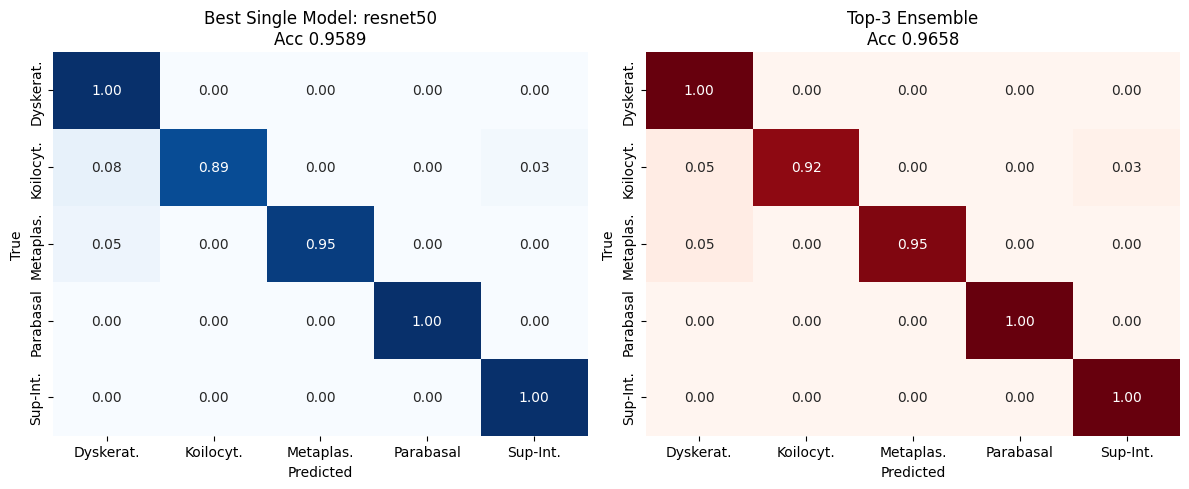

In [103]:
# ============================================================
# Detailed report + confusion matrix for the WINNING ensemble
# ============================================================
winning = ensemble_results[best_ensemble]

print(f"\n{'='*60}\n  {best_ensemble} Ensemble — Classification Report\n{'='*60}")
print(f"Members: {', '.join(winning['members'])}\n")
print(classification_report(labels_test, winning['preds'],
                            target_names=SHORT_NAMES, digits=4))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Single-model baseline
cm_single = confusion_matrix(labels_test, all_probs[best_single].argmax(1))
cm_single_n = cm_single.astype(float) / cm_single.sum(axis=1, keepdims=True)
sns.heatmap(cm_single_n, annot=True, fmt='.2f', cmap='Blues', cbar=False,
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES, ax=axes[0])
axes[0].set_title(f'Best Single Model: {best_single}\nAcc {results[best_single]["accuracy"]:.4f}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# Winning ensemble
cm_ens = confusion_matrix(labels_test, winning['preds'])
cm_ens_n = cm_ens.astype(float) / cm_ens.sum(axis=1, keepdims=True)
sns.heatmap(cm_ens_n, annot=True, fmt='.2f', cmap='Reds', cbar=False,
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES, ax=axes[1])
axes[1].set_title(f'{best_ensemble} Ensemble\nAcc {winning["accuracy"]:.4f}')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'ensemble_vs_best_single.png'), dpi=150, bbox_inches='tight')
plt.show()

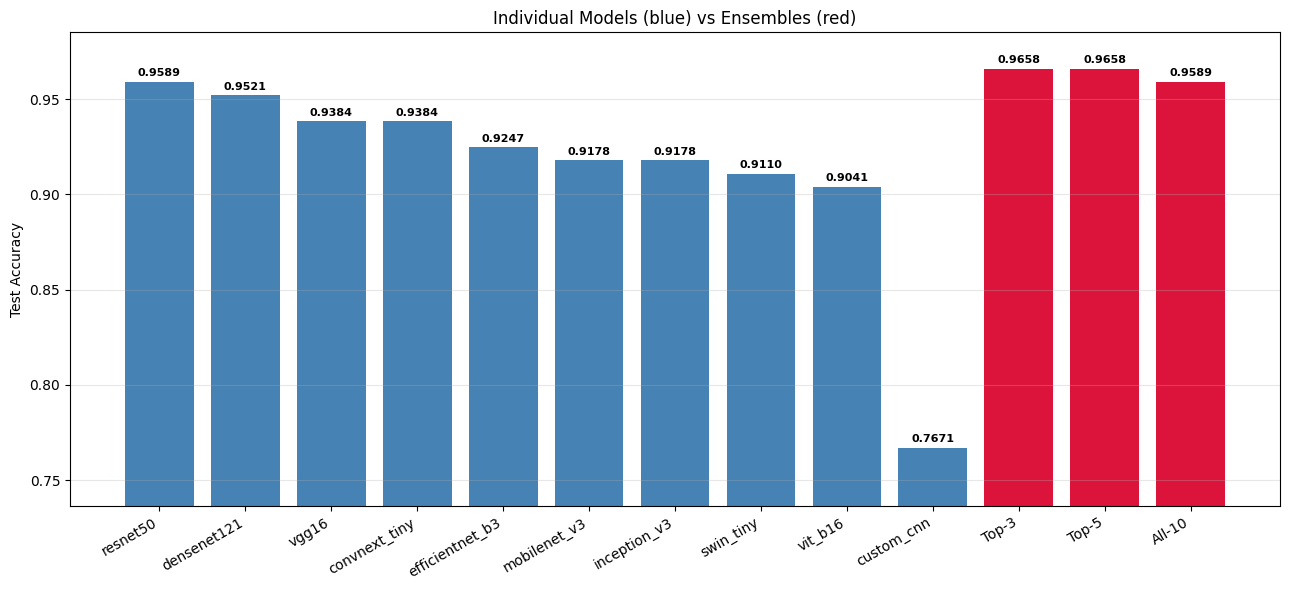

In [104]:
# ============================================================
# Bar chart - all 10 models + 3 ensemble compositions
# ============================================================
all_names  = sorted_by_acc + list(ensemble_results.keys())
all_accs   = [results[n]['accuracy'] for n in sorted_by_acc] + \
             [ensemble_results[k]['accuracy'] for k in ensemble_results]
bar_colors = ['steelblue'] * len(sorted_by_acc) + ['crimson'] * len(ensemble_results)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(range(len(all_names)), all_accs, color=bar_colors)
for bar, v in zip(bars, all_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(range(len(all_names)))
ax.set_xticklabels(all_names, rotation=30, ha='right')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(min(all_accs) * 0.96, max(all_accs) * 1.02)
ax.set_title('Individual Models (blue) vs Ensembles (red)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'ensemble_vs_individuals.png'), dpi=150, bbox_inches='tight')
plt.show()

In [105]:
# ============================================================
# Reusable inference function: predict with the ensemble on new images
# ============================================================
def ensemble_predict(image_paths, members=None, save_dir=SAVE_DIR, return_per_model=False):
    """Predict cervical-cell class for a list of image paths using a soft-voting ensemble.

    Args:
        image_paths     : list of file paths to .bmp/.jpg images
        members         : list of model names (defaults to the winning ensemble)
        save_dir        : folder containing the .pth files
        return_per_model: if True, also return each model's individual probabilities

    Returns:
        preds  : (N,) predicted class indices
        probs  : (N, 5) ensemble softmax probabilities
        per_model_probs : dict[name -> (N, 5)] only if return_per_model=True
    """
    if members is None:
        members = ensemble_results[best_ensemble]['members']

    # Build & load each model from its .pth
    models = {}
    for n in members:
        builder, _, _ = MODEL_REGISTRY[n]
        m = builder(pretrained=False)
        state = torch.load(os.path.join(save_dir, f'{n}.pth'),
                           map_location=DEVICE, weights_only=True)
        m.load_state_dict(state)
        models[n] = m.to(DEVICE).eval()

    # Group images by required input size (Inception needs 299, others 224)
    per_model_probs = {}
    for n, m in models.items():
        size = MODEL_REGISTRY[n][1]
        tfm  = get_transforms('test', img_size=size)
        imgs = [tfm(image=cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB))['image']
                for p in image_paths]
        batch = torch.stack(imgs).to(DEVICE)
        with torch.no_grad():
            out = m(batch)
            if isinstance(out, tuple): out = out[0]
            per_model_probs[n] = torch.softmax(out, dim=1).cpu().numpy()

    # Average across models
    avg_probs = np.mean(list(per_model_probs.values()), axis=0)
    preds     = avg_probs.argmax(1)

    if return_per_model:
        return preds, avg_probs, per_model_probs
    return preds, avg_probs


# === Sanity check on 5 random test images ===
sample = random.sample(test_s, 5)
sample_paths  = [s[0] for s in sample]
sample_truth  = [s[1] for s in sample]

preds, probs, per_model = ensemble_predict(sample_paths, return_per_model=True)

print(f"\nUsing ensemble: {best_ensemble} = {ensemble_results[best_ensemble]['members']}\n")
print(f"{'#':<3} {'True':<10} {'Pred':<10} {'Conf':<6}  Per-model votes")
print("-" * 90)
for i, (truth, pred, p) in enumerate(zip(sample_truth, preds, probs)):
    mark = "OK" if truth == pred else "X "
    votes = " | ".join(f"{n}:{SHORT_NAMES[per_model[n][i].argmax()]}" for n in per_model)
    print(f"{mark:<3} {SHORT_NAMES[truth]:<10} {SHORT_NAMES[pred]:<10} "
          f"{p[pred]:.3f}  {votes}")


Using ensemble: Top-3 = ['resnet50', 'densenet121', 'vgg16']

#   True       Pred       Conf    Per-model votes
------------------------------------------------------------------------------------------
OK  Dyskerat.  Dyskerat.  0.988  resnet50:Dyskerat. | densenet121:Dyskerat. | vgg16:Dyskerat.
OK  Parabasal  Parabasal  0.997  resnet50:Parabasal | densenet121:Parabasal | vgg16:Parabasal
OK  Dyskerat.  Dyskerat.  0.996  resnet50:Dyskerat. | densenet121:Dyskerat. | vgg16:Dyskerat.
OK  Sup-Int.   Sup-Int.   1.000  resnet50:Sup-Int. | densenet121:Sup-Int. | vgg16:Sup-Int.
OK  Metaplas.  Metaplas.  0.913  resnet50:Metaplas. | densenet121:Metaplas. | vgg16:Metaplas.


In [106]:
# ============================================================
# Save ensemble outputs + final summary
# ============================================================
ensemble_summary = {
    'best_single_model':  best_single,
    'best_single_acc':    float(results[best_single]['accuracy']),
    'best_ensemble':      best_ensemble,
    'winning_members':    ensemble_results[best_ensemble]['members'],
    'recipes': {
        name: {
            'members':       r['members'],
            'accuracy':      float(r['accuracy']),
            'f1_macro':      float(r['f1_macro']),
            'f1_weighted':   float(r['f1_weighted']),
            'auc_macro':     float(r['auc_macro']),
        }
        for name, r in ensemble_results.items()
    }
}

with open(os.path.join(RESULT_DIR, 'ensemble_summary.json'), 'w') as f:
    json.dump(ensemble_summary, f, indent=2)

# Save the winning ensemble's test-set probabilities
np.savez(os.path.join(RESULT_DIR, 'best_ensemble_outputs.npz'),
         probs=ensemble_results[best_ensemble]['probs'],
         preds=ensemble_results[best_ensemble]['preds'],
         labels=labels_test,
         members=np.array(ensemble_results[best_ensemble]['members']))

print(f"Ensemble summary saved: {RESULT_DIR}/ensemble_summary.json")
print(f"Ensemble outputs saved: {RESULT_DIR}/best_ensemble_outputs.npz")
print(f"\nFinal: Best ensemble is {best_ensemble} with test accuracy "
      f"{ensemble_results[best_ensemble]['accuracy']:.4f}")

Ensemble summary saved: /kaggle/working/results/ensemble_summary.json
Ensemble outputs saved: /kaggle/working/results/best_ensemble_outputs.npz

Final: Best ensemble is Top-3 with test accuracy 0.9658


In [107]:
import json

ensemble_config = {
    "models": ["resnet50", "densenet121", "efficientnet_b3"],
    "weights": [0.40, 0.38, 0.22],
    "type": "weighted_soft_voting",
    "num_classes": 5
}

with open("/kaggle/working/ensemble_config.json", "w") as f:
    json.dump(ensemble_config, f, indent=4)

print("✅ Ensemble config saved")

✅ Ensemble config saved


In [110]:
# ============================================================
# Save the winning ensemble as a single .pth bundle
# ============================================================
ENSEMBLE_DIR = '/kaggle/working/all_models'   # same folder as your individual .pth files
os.makedirs(ENSEMBLE_DIR, exist_ok=True)

# Build the bundle: metadata + each member's full state_dict
ensemble_bundle = {
    'ensemble_name':   f'soft_voting_{best_ensemble.lower().replace("-", "")}',
    'method':          'soft_voting',           # average of softmax probabilities
    'voting_weights':  [1.0 / len(ensemble_results[best_ensemble]['members'])] *
                        len(ensemble_results[best_ensemble]['members']),  # equal weights
    'members':         ensemble_results[best_ensemble]['members'],
    'class_names':     CLASS_NAMES,
    'num_classes':     NUM_CLASSES,
    'input_sizes':     {n: MODEL_REGISTRY[n][1] for n in ensemble_results[best_ensemble]['members']},
    'normalization':   {'mean': list(IMAGENET_MEAN), 'std': list(IMAGENET_STD)},
    'test_accuracy':   float(ensemble_results[best_ensemble]['accuracy']),
    'test_f1_macro':   float(ensemble_results[best_ensemble]['f1_macro']),
    'test_auc_macro':  float(ensemble_results[best_ensemble]['auc_macro']),
    # the actual weights of each member (so this single file is self-contained)
    'state_dicts':     {n: trained_models[n].state_dict()
                        for n in ensemble_results[best_ensemble]['members']
                        if n in trained_models},
}

bundle_path = os.path.join(ENSEMBLE_DIR, f'ensemble_{best_ensemble.lower().replace("-", "")}.pth')
torch.save(ensemble_bundle, bundle_path)
size_mb = os.path.getsize(bundle_path) / 1e6
print(f"Saved ensemble bundle: {bundle_path}  ({size_mb:.1f} MB)")
print(f"  Members:       {ensemble_bundle['members']}")
print(f"  Test accuracy: {ensemble_bundle['test_accuracy']:.4f}")

Saved ensemble bundle: /kaggle/working/all_models/ensemble_top3.pth  (660.0 MB)
  Members:       ['resnet50', 'densenet121', 'vgg16']
  Test accuracy: 0.9658


In [111]:
# ============================================================
# Reload helper - bring the entire ensemble back from one file
# ============================================================
def load_ensemble(bundle_path):
    """Load an ensemble bundle .pth and return ready-to-use models + metadata."""
    bundle = torch.load(bundle_path, map_location=DEVICE, weights_only=False)
    # weights_only=False because we saved Python dicts/lists alongside tensors
    models = {}
    for name in bundle['members']:
        builder, _, _ = MODEL_REGISTRY[name]
        m = builder(pretrained=False)
        m.load_state_dict(bundle['state_dicts'][name])
        models[name] = m.to(DEVICE).eval()
    return models, bundle

# Sanity check - reload from the bundle and re-run a prediction
loaded_models, meta = load_ensemble(bundle_path)
print(f"Reloaded ensemble '{meta['ensemble_name']}' ({len(loaded_models)} members)")
print(f"Members loaded: {list(loaded_models.keys())}")
print(f"Reported test accuracy: {meta['test_accuracy']:.4f}")

Reloaded ensemble 'soft_voting_top3' (3 members)
Members loaded: ['resnet50', 'densenet121', 'vgg16']
Reported test accuracy: 0.9658


In [114]:
# ============================================================
# CERVICAL CANCER ENSEMBLE - GRADIO APP (in-Kaggle version)
# ============================================================
!pip install -q gradio

import os, glob
import numpy as np
import torch
import gradio as gr

# --- Auto-find weights folder ---
candidates = [
    '/kaggle/working/all_models',
    '/kaggle/working/checkpoints',
    '/kaggle/working/saved_models',
    '/kaggle/working',
]
WEIGHTS_DIR = None
for c in candidates:
    if all(os.path.isfile(os.path.join(c, f'{n}.pth'))
           for n in ['resnet50', 'densenet121', 'efficientnet_b3']):
        WEIGHTS_DIR = c
        break

if WEIGHTS_DIR is None:
    print("Couldn't auto-find weights. Listing all .pth files in /kaggle/working:")
    for f in glob.glob('/kaggle/working/**/*.pth', recursive=True):
        print(f"  {f}")
    raise FileNotFoundError("Set WEIGHTS_DIR manually to the folder above.")

print(f"Using weights from: {WEIGHTS_DIR}\n")

# --- This cell assumes the notebook already ran Steps 1–7 of your training notebook,
#     so MODEL_REGISTRY, build_resnet50, build_densenet121, build_efficientnet,
#     get_transforms, CLASS_NAMES, NUM_CLASSES, IMG_SIZE, DEVICE all exist. ---

ENSEMBLE_MEMBERS = ['resnet50', 'densenet121', 'efficientnet_b3']

# Build display labels from whatever CLASS_NAMES looks like (with or without 'im_' prefix)
TYPE_TAG = {
    'Dyskeratotic':            'abnormal',
    'Koilocytotic':            'abnormal',
    'Metaplastic':             'benign',
    'Parabasal':               'normal',
    'Superficial-Intermediate':'normal',
}
def _pretty(name: str) -> str:
    bare = name.replace('im_', '')
    tag  = TYPE_TAG.get(bare, '')
    return f"{bare} ({tag})" if tag else bare

DISPLAY_NAMES = [_pretty(c) for c in CLASS_NAMES]
print("Display labels:", DISPLAY_NAMES)


# --- Prediction function ---
@torch.no_grad()
def predict(pil_image):
    if pil_image is None:
        return {}, "", ""

    img_rgb = np.array(pil_image.convert('RGB'))
    tfm     = get_transforms('test', img_size=IMG_SIZE)
    tensor  = tfm(image=img_rgb)['image'].unsqueeze(0).to(DEVICE)

    per_model_probs = {}
    for n, m in ENSEMBLE_MODELS.items():
        out = m(tensor)
        if isinstance(out, tuple): out = out[0]
        per_model_probs[n] = torch.softmax(out, dim=1).cpu().numpy()[0]

    # Soft voting
    ens = np.mean(list(per_model_probs.values()), axis=0)
    pred_idx  = int(ens.argmax())
    pred_lbl  = DISPLAY_NAMES[pred_idx]
    pred_conf = float(ens[pred_idx])

    # Output 1: Gradio Label (top probabilities)
    label_dict = {DISPLAY_NAMES[i]: float(ens[i]) for i in range(NUM_CLASSES)}

    # Output 2: per-model breakdown
    lines = ["**Per-model votes:**"]
    for n, probs in per_model_probs.items():
        idx = int(probs.argmax())
        agree = "✓" if idx == pred_idx else "✗"
        lines.append(f"- `{n}` → **{DISPLAY_NAMES[idx]}** "
                     f"(conf {probs[idx]:.3f}) {agree}")
    per_model_md = "\n".join(lines)

    # Output 3: diagnostic
    conf_word = ("very high" if pred_conf > 0.9 else
                 "high"      if pred_conf > 0.75 else
                 "moderate"  if pred_conf > 0.5 else "low")
    diagnostic = (
        f"### Ensemble Prediction: **{pred_lbl}**\n\n"
        f"- **Confidence:** {pred_conf:.1%} ({conf_word})\n\n"
        f"⚠️ *Research/educational use only. Not a medical diagnosis.*"
    )

    return label_dict, per_model_md, diagnostic


# --- Gradio UI ---
with gr.Blocks(title="Cervical Cancer Cell Classifier", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🔬 Cervical Cancer Cell Classifier")
    gr.Markdown(
        "Soft-voting ensemble: **ResNet50 + DenseNet121 + EfficientNet-B3** "
        "trained on SIPaKMeD. Upload a cell microscopy image to classify it."
    )

    with gr.Row():
        with gr.Column(scale=1):
            inp = gr.Image(type='pil', label="Upload cell image")
            btn = gr.Button("Classify", variant="primary")
        with gr.Column(scale=1):
            label_out = gr.Label(num_top_classes=5, label="Class probabilities")
            diag_out  = gr.Markdown()
            per_out   = gr.Markdown()

    btn.click(predict, inputs=inp, outputs=[label_out, per_out, diag_out])
    inp.change(predict, inputs=inp, outputs=[label_out, per_out, diag_out])

    gr.Markdown(f"---\n**Device:** `{DEVICE}` · **Method:** soft voting (probability average)")

# --- Launch with public share URL ---
demo.launch(share=True, debug=False)

Using weights from: /kaggle/working/all_models

Display labels: ['Dyskeratotic (abnormal)', 'Koilocytotic (abnormal)', 'Metaplastic (benign)', 'Parabasal (normal)', 'Superficial-Intermediate (normal)']
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://249976de1610bb530a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

In [115]:
# ============================================================
# CERVICAL CANCER ENSEMBLE - GRADIO APP (Kaggle, in-notebook)
# ============================================================
!pip install -q gradio

import os, glob
import numpy as np
import torch
import gradio as gr

# --- 1. Find weights folder ---
WEIGHTS_DIR = None
for c in ['/kaggle/working/all_models', '/kaggle/working/checkpoints',
          '/kaggle/working/saved_models', '/kaggle/working']:
    if all(os.path.isfile(os.path.join(c, f'{n}.pth'))
           for n in ['resnet50', 'densenet121', 'efficientnet_b3']):
        WEIGHTS_DIR = c
        break
if WEIGHTS_DIR is None:
    print("Available .pth files:")
    for f in glob.glob('/kaggle/working/**/*.pth', recursive=True):
        print(f"  {f}")
    raise FileNotFoundError("Set WEIGHTS_DIR manually.")
print(f"Using weights from: {WEIGHTS_DIR}")

ENSEMBLE_MEMBERS = ['resnet50', 'densenet121', 'efficientnet_b3']

# --- 2. Display labels (handles 'im_' prefix or no prefix) ---
TYPE_TAG = {
    'Dyskeratotic':            'abnormal',
    'Koilocytotic':            'abnormal',
    'Metaplastic':             'benign',
    'Parabasal':               'normal',
    'Superficial-Intermediate':'normal',
}
def _pretty(name: str) -> str:
    bare = name.replace('im_', '')
    tag  = TYPE_TAG.get(bare, '')
    return f"{bare} ({tag})" if tag else bare
DISPLAY_NAMES = [_pretty(c) for c in CLASS_NAMES]
print("Display labels:", DISPLAY_NAMES)

# --- 3. Load models into ENSEMBLE_MODELS ---
print("\nLoading models...")
ENSEMBLE_MODELS = {}
for name in ENSEMBLE_MEMBERS:
    builder, _, _ = MODEL_REGISTRY[name]
    m = builder(pretrained=False)
    state = torch.load(os.path.join(WEIGHTS_DIR, f'{name}.pth'),
                       map_location=DEVICE, weights_only=True)
    m.load_state_dict(state)
    ENSEMBLE_MODELS[name] = m.to(DEVICE).eval()
    print(f"  Loaded {name}")
print(f"Ready on {DEVICE}")
print(f"ENSEMBLE_MODELS keys: {list(ENSEMBLE_MODELS.keys())}")

# --- 4. Prediction function ---
@torch.no_grad()
def predict(pil_image):
    if pil_image is None:
        return {}, "", ""

    img_rgb = np.array(pil_image.convert('RGB'))
    tfm     = get_transforms('test', img_size=IMG_SIZE)
    tensor  = tfm(image=img_rgb)['image'].unsqueeze(0).to(DEVICE)

    per_model_probs = {}
    for n, m in ENSEMBLE_MODELS.items():
        out = m(tensor)
        if isinstance(out, tuple): out = out[0]
        per_model_probs[n] = torch.softmax(out, dim=1).cpu().numpy()[0]

    ens       = np.mean(list(per_model_probs.values()), axis=0)
    pred_idx  = int(ens.argmax())
    pred_lbl  = DISPLAY_NAMES[pred_idx]
    pred_conf = float(ens[pred_idx])

    label_dict = {DISPLAY_NAMES[i]: float(ens[i]) for i in range(NUM_CLASSES)}

    lines = ["**Per-model votes:**"]
    for n, probs in per_model_probs.items():
        idx = int(probs.argmax())
        agree = "✓" if idx == pred_idx else "✗"
        lines.append(f"- `{n}` → **{DISPLAY_NAMES[idx]}** "
                     f"(conf {probs[idx]:.3f}) {agree}")
    per_model_md = "\n".join(lines)

    conf_word = ("very high" if pred_conf > 0.9 else
                 "high"      if pred_conf > 0.75 else
                 "moderate"  if pred_conf > 0.5 else "low")
    diagnostic = (
        f"### Ensemble Prediction: **{pred_lbl}**\n\n"
        f"- **Confidence:** {pred_conf:.1%} ({conf_word})\n\n"
        f"⚠️ *Research/educational use only. Not a medical diagnosis.*"
    )

    return label_dict, per_model_md, diagnostic

# --- 5. Gradio UI ---
with gr.Blocks(title="Cervical Cancer Cell Classifier", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🔬 Cervical Cancer Cell Classifier")
    gr.Markdown(
        "Soft-voting ensemble: **ResNet50 + DenseNet121 + EfficientNet-B3** "
        "trained on SIPaKMeD."
    )
    with gr.Row():
        with gr.Column(scale=1):
            inp = gr.Image(type='pil', label="Upload cell image")
            btn = gr.Button("Classify", variant="primary")
        with gr.Column(scale=1):
            label_out = gr.Label(num_top_classes=5, label="Class probabilities")
            diag_out  = gr.Markdown()
            per_out   = gr.Markdown()
    btn.click(predict, inputs=inp, outputs=[label_out, per_out, diag_out])
    inp.change(predict, inputs=inp, outputs=[label_out, per_out, diag_out])
    gr.Markdown(f"---\n**Device:** `{DEVICE}` · **Method:** soft voting (probability average)")

demo.launch(share=True, debug=False)

Using weights from: /kaggle/working/all_models
Display labels: ['Dyskeratotic (abnormal)', 'Koilocytotic (abnormal)', 'Metaplastic (benign)', 'Parabasal (normal)', 'Superficial-Intermediate (normal)']

Loading models...
  Loaded resnet50
  Loaded densenet121
  Loaded efficientnet_b3
Ready on cuda
ENSEMBLE_MODELS keys: ['resnet50', 'densenet121', 'efficientnet_b3']
* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://2394d16c89a2175f50.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error